# A08 - Transfer Learning

Este notebook prepara e treina um pipeline de **transfer learning** sobre o
mesmo dataset usado nos artefatos anteriores:

- `artefatos/a02_baseline_classico/a02_baseline_classico.ipynb`
- `artefatos/a05_cnn_simples/a05_cnn_simples.ipynb`

O foco aqui é consolidar a etapa de dados no formato certo para backbones
pré-treinados:

- split `treino/validação/teste` com controle por `image_id`;
- conversão dos `pixel_*` para tensor 4D;
- `resize` espacial para o tamanho do backbone;
- normalização ajustada **apenas** no treino;
- `data augmentation` apenas no treino.

## Protocolo de dados

A lógica foi movida para o código reutilizável do projeto:

- `src/models/cnn_data_prep.py`
- `src/models/cnn_tf_data_pipeline.py`

Isso evita reimplementar manualmente no notebook a mesma etapa em cada artefato.

In [1]:
import importlib.util
import subprocess
import sys

PYTHON_VERSION = sys.version_info[:3]
REQUIRED_PACKAGES = {
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

if PYTHON_VERSION < (3, 10) or PYTHON_VERSION >= (3, 13):
    raise RuntimeError(
        "Este notebook de A08 foi preparado para rodar com TensorFlow em Python 3.10, 3.11 ou 3.12. "
        f"Ambiente atual: {sys.version.split()[0]}. "
        "Use Google Colab ou um ambiente local com Python 3.11/3.12."
    )

REQUIRED_PACKAGES["tensorflow"] = "tensorflow"

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Dependências OK.")

Dependências OK.


In [2]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tensorflow import keras
from tensorflow.keras import layers


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = resolve_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from models.cnn_builder import build_transfer_model, unfreeze_backbone_layers
from models.cnn_data_prep import prepare_grouped_cnn_splits
from models.cnn_tf_data_pipeline import build_train_val_test_tf_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_CSV = PROJECT_ROOT / "data" / "pixels_dataset.csv"
EXTRACTED_CODES_JSON = PROJECT_ROOT / "data" / "extracted_codes.json"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "a08_transfer_learning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.20
VAL_SIZE = 0.20
BATCH_SIZE = 8
TARGET_SIZE = (160, 160)
NORMALIZATION = "zscore"

# --- Fase 1: Head Training (backbone congelado) ---
HEAD_EPOCHS = 6
HEAD_LEARNING_RATE = 1e-4

# --- Fase 2: Fine-Tuning (últimas camadas do backbone descongeladas) ---
FINE_TUNE_EPOCHS = 12
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAST_LAYERS = 20

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dataset: {DATASET_CSV}")
print(f"Códigos: {EXTRACTED_CODES_JSON}")
print(f"Saída: {OUTPUT_DIR}")

Projeto: /Users/mateus/Projetos/Academico/Inteli/g01
Dataset: /Users/mateus/Projetos/Academico/Inteli/g01/data/pixels_dataset.csv
Códigos: /Users/mateus/Projetos/Academico/Inteli/g01/data/extracted_codes.json
Saída: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a08_transfer_learning


In [3]:
assert DATASET_CSV.exists(), f"Arquivo não encontrado: {DATASET_CSV}"
assert EXTRACTED_CODES_JSON.exists(), f"Arquivo não encontrado: {EXTRACTED_CODES_JSON}"

df = pd.read_csv(DATASET_CSV)

split_data = prepare_grouped_cnn_splits(
    df,
    extracted_codes_path=EXTRACTED_CODES_JSON,
    data_format="channels_last",
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

prep_summary = {
    "dataset_rows": int(len(df)),
    "valid_rows": int(split_data["split_meta"]["n_valid"]),
    "input_shape_raw": (
        int(split_data["shape_info"]["height"]),
        int(split_data["shape_info"]["width"]),
        int(split_data["shape_info"]["n_channels"]),
    ),
    "train_samples": int(split_data["split_meta"]["n_train"]),
    "val_samples": int(split_data["split_meta"]["n_val"]),
    "test_samples": int(split_data["split_meta"]["n_test"]),
    "train_images": int(len(split_data["split_meta"]["train_ids"])),
    "val_images": int(len(split_data["split_meta"]["val_ids"])),
    "test_images": int(len(split_data["split_meta"]["test_ids"])),
}

display(pd.DataFrame([prep_summary]))

,dataset_rows,valid_rows,input_shape_raw,train_samples,val_samples,test_samples,train_images,val_images,test_images
0,295,295,"(128, 128, 9)",177,59,59,177,59,59


In [4]:
tf_data = build_train_val_test_tf_data(
    split_data["X_train"],
    split_data["y_train"],
    split_data["X_val"],
    split_data["y_val"],
    split_data["X_test"],
    split_data["y_test"],
    batch_size=BATCH_SIZE,
    normalization=NORMALIZATION,
    resize_to=TARGET_SIZE,
    data_format="channels_last",
    target_channels=split_data["shape_info"]["n_channels"],
    augment_train=True,
    seed=SEED,
)

data_overview = pd.DataFrame(
    [
        {
            "split": "train",
            "samples": tf_data["train_meta"]["n_samples"],
            "input_shape": tf_data["train_meta"]["input_shape"],
            "augment": tf_data["train_meta"]["augment"],
        },
        {
            "split": "val",
            "samples": tf_data["val_meta"]["n_samples"],
            "input_shape": tf_data["val_meta"]["input_shape"],
            "augment": tf_data["val_meta"]["augment"],
        },
        {
            "split": "test",
            "samples": tf_data["test_meta"]["n_samples"],
            "input_shape": tf_data["test_meta"]["input_shape"],
            "augment": tf_data["test_meta"]["augment"],
        },
    ]
)
display(data_overview)

,split,samples,input_shape,augment
0,train,177,"(160, 160, 9)",True
1,val,59,"(160, 160, 9)",False
2,test,59,"(160, 160, 9)",False


## Decisão de arquitetura

O dataset ASTER possui `9` bandas, enquanto o `MobileNetV2` pré-treinado em
ImageNet espera `3` canais. Em vez de descartar bandas, o notebook usa uma
**camada adaptadora `1x1`** para projetar a entrada `9 → 3` antes do backbone.

### Descrição e Justificativa da Adaptação
Nesta etapa, adaptamos a entrada do modelo para viabilizar o uso de redes pré-treinadas no ImageNet (que exigem 3 canais) com os dados do sensor ASTER (9 bandas).

Utilizamos uma camada de Convolução 1x1 para realizar uma combinação linear das bandas multiespectrais, comprimindo-as em 3 canais latentes antes de entrarem na base da rede. Isso permite que o modelo utilize pesos pré-treinados sem descartar a riqueza de dados das bandas SWIR.

### Código de Construção do Modelo (Foco em Teste)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_transfer_learning_test_model(input_shape=(128, 128, 9), n_classes=2):
    """
     Esta função constrói um modelo de transferência de aprendizado usando MobileNetV2 como base,
     adaptando a entrada de 9 bandas para 3 canais, e finalizando com uma camada de saída.
     """
    # 1. BASE: MobileNetV2 pré-treinada
    # Instanciamos com 3 canais para garantir o carregamento correto dos pesos [cite: 142]
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(input_shape[0], input_shape[1], 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False # Congelado para validação inicial [cite: 65]

    # 2. ENTRADA: Suporta os chips de 9 bandas ASTER [cite: 8, 132]
    inputs = layers.Input(shape=input_shape, name="aster_9_bands_input")

    # 3. ADAPTAÇÃO: Conv 1x1 mapeia 9 canais -> 3 canais latentes
    # Essencial para a evolução do modelo conforme o Artefato A08
    x = layers.Conv2D(3, (1, 1), padding='same', name='spectral_adapter')(inputs)

    # 4. CONEXÃO: Passa o output do adaptador para a base pré-treinada
    x = base_model(x, training=False)

    # 5. SAÍDA: Camada densa final para classificação binária [cite: 24, 40]
    outputs = layers.Dense(n_classes, activation='sigmoid', name='output_tl')(x)

    return Model(inputs, outputs, name="SpectraAI_TL_v1_Fixed")

### Execução do Forward Pass e Documentação de Resultados
Aqui realizamos a verificação das dimensões de entrada/saída para garantir a compatibilidade com os dados do projeto.

In [6]:
# 1. Instanciar o modelo adaptado
# Esta chamada agora deve carregar os pesos sem erros [cite: 41]
model_tl = build_transfer_learning_test_model()

# 2. Criar dado sintético (Simulando 1 chip multiespectral do grupo: 128x128x9)
# Garante a compatibilidade com o output do 'recortar_banda' [cite: 128, 140]
dummy_input = tf.random.uniform((1, 128, 128, 9))

print("--- RELATÓRIO TÉCNICO: ---")
print(f"Dimensão de Entrada (Original ASTER): {dummy_input.shape}")

# 3. Execução do Forward Pass
try:
    # Teste de inferência para verificar fluxo de dados [cite: 120]
    prediction = model_tl(dummy_input, training=False)
    
    print(f"Dimensão de Saída (Predição Final):  {prediction.shape}")
    
    # Validação lógica do sucesso do teste conforme conversa com o grupo
    if prediction.shape == (1, 2):
        print("\nSTATUS: SUCESSO")
        print("DOCUMENTAÇÃO: O modelo processou 9 bandas e retornou probabilidades binárias.")
        print("VERIFICAÇÃO: Conexão entre Adaptador e Base validada com sucesso.")
except Exception as e:
    print(f"\nSTATUS: FALHA NO FORWARD PASS: {e}")

# Exibir o sumário para documentação oficial do Artefato A08 [cite: 46, 115]
model_tl.summary()

--- RELATÓRIO TÉCNICO: ---
Dimensão de Entrada (Original ASTER): (1, 128, 128, 9)
Dimensão de Saída (Predição Final):  (1, 2)

STATUS: SUCESSO
DOCUMENTAÇÃO: O modelo processou 9 bandas e retornou probabilidades binárias.
VERIFICAÇÃO: Conexão entre Adaptador e Base validada com sucesso.


Model: "SpectraAI_TL_v1_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aster_9_bands_input             │ (None, 128, 128, 9)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_adapter (Conv2D)       │ (None, 128, 128, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_tl (Dense)               │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,576 (8.62 MB)

 Trainable params: 2,592 (10.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Resultados do Teste de Forward Pass e Validação de Arquitetura

Nesta etapa, validamos a viabilidade técnica de integrar o sensor multiespectral **ASTER** com a arquitetura pré-treinada **MobileNetV2**. O foco principal foi garantir que a informação espectral das 9 bandas fosse preservada e corretamente mapeada para o espaço latente de 3 canais exigido pela base de transferência.

#### **Justificativa Técnica da Adaptação**
Como modelos baseados em ImageNet são otimizados para 3 canais RGB, a implementação da camada `spectral_adapter` (Conv2D 1x1) permitiu:
* **Preservação de Dados:** Combinação linear das 9 bandas originais (VNIR + SWIR).
* **Compatibilidade:** Redução dimensional para os 3 canais esperados pela `mobilenetv2_1.00_128`.
* **Eficiência:** Adição de apenas 30 parâmetros treináveis na entrada, mantendo a leveza do modelo.

#### **Relatório de Execução do Teste**
O teste de forward pass simulou a entrada de um chip multiespectral de 128x128 pixels.

| Parâmetro de Teste | Valor Observado | Status |
| :--- | :--- | :--- |
| **Dimensão de Entrada (ASTER)** | $(1, 128, 128, 9)$ | Nominal |
| **Dimensão Pós-Adaptação** | $(None, 128, 128, 3)$ | Nominal |
| **Dimensão de Saída (Predição)** | $(1, 2)$ | Nominal |
| **Status do Fluxo de Dados** | **SUCESSO** | Validado |

>**Nota de Documentação:** O modelo processou as 9 bandas espectrais com sucesso e retornou probabilidades binárias para a classe de prospectividade de Terras Raras. A conexão entre o adaptador customizado e a base funcional foi validada sem erros de carregamento de pesos.

#### **Resumo da Arquitetura Evoluída**
Abaixo, detalhamos a contagem de parâmetros para a estratégia de **Transfer Learning** inicial:

* **Total de Parâmetros:** 2.260.576 (~8.62 MB).
* **Parâmetros Treináveis:** 2.592 (Apenas a Camada de Adaptação e a Cabeça Dense).
* **Parâmetros Congelados:** 2.257.984 (Base MobileNetV2).

In [7]:
model, model_info = build_transfer_model(
    input_shape=tf_data["train_meta"]["input_shape"],
    learning_rate=HEAD_LEARNING_RATE,
)
model.summary()
model_info

Model: "a08_transfer_learning_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aster_9ch_input (InputLayer)    │ (None, 160, 160, 9)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter (Conv2D)        │ (None, 160, 160, 3)    │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter_bn              │ (None, 160, 160, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter_relu            │ (None, 160, 160, 3)    │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,304 (8.62 MB)

 Trainable params: 1,314 (5.13 KB)

 Non-trainable params: 2,257,990 (8.61 MB)

{'backbone': 'MobileNetV2',
 'pretrained_loaded': True,
 'phase': 'head_training',
 'input_shape': (160, 160, 9),
 'learning_rate': 0.0001,
 'dropout_rate': 0.25}

## Pipeline de treinamento em duas fases

A estratégia de transfer learning segue duas fases distintas:

| Fase | Descrição | Backbone | Camadas treináveis | Learning Rate |
|------|-----------|----------|-------------------|---------------|
| **1 — Head Training** | Treina apenas o adaptador de canais (Conv2D 1×1) e a cabeça de classificação (Dense). O backbone MobileNetV2 permanece **totalmente congelado**. | Congelado | Adapter + Head | `1e-4` |
| **2 — Fine-Tuning** | Desbloqueia as últimas 20 camadas do backbone (exceto BatchNormalization) e continua o treino com LR reduzido para ajuste fino. | Parcialmente descongelado | Adapter + Head + Últimas 20 camadas | `1e-5` |

Essa abordagem evita **catastrophic forgetting**: a fase 1 adapta o head ao domínio ASTER sem corromper os pesos ImageNet, e a fase 2 refina apenas as camadas superiores do backbone com taxa conservadora.

### Fase 1 — Head Training (backbone congelado)

Nesta fase treinamos **apenas** a camada adaptadora (Conv2D 1×1 + BN) e a cabeça
de classificação (Dense sigmoid). O backbone MobileNetV2 permanece totalmente
congelado para preservar os pesos pré-treinados do ImageNet.

**Callbacks utilizados:**
- `EarlyStopping`: interrompe o treino se `val_loss` não melhorar por 3 épocas.
- `ReduceLROnPlateau`: reduz o LR pela metade se `val_loss` estagnar por 2 épocas.

In [8]:
# Verificação: apenas adapter + head são treináveis na fase 1
trainable_names_phase1 = [w.name for w in model.trainable_weights]
print(f"Fase 1 — Parâmetros treináveis: {len(trainable_names_phase1)}")
for name in trainable_names_phase1:
    print(f"  {name}")

total_p1 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
frozen_p1 = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)
print(f"\nTreináveis: {total_p1:,} | Congelados: {frozen_p1:,}")

Fase 1 — Parâmetros treináveis: 5
  kernel
  gamma
  beta
  kernel
  bias

Treináveis: 1,314 | Congelados: 2,257,990


In [9]:
callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print(f"Fase 1 — Head Training: {HEAD_EPOCHS} épocas, LR={HEAD_LEARNING_RATE}")
history_phase1 = model.fit(
    tf_data["train_ds"],
    validation_data=tf_data["val_ds"],
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)

Fase 1 — Head Training: 6 épocas, LR=0.0001
Epoch 1/6
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.4124 - loss: 1.0873 - pr_auc: 0.3533 - precision: 0.3924 - recall: 0.8857 - roc_auc: 0.4487 - val_accuracy: 0.4237 - val_loss: 0.9734 - val_pr_auc: 0.3821 - val_precision: 0.4035 - val_recall: 1.0000 - val_roc_auc: 0.5290 - learning_rate: 1.0000e-04
Epoch 2/6
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4915 - loss: 0.9072 - pr_auc: 0.3674 - precision: 0.4219 - recall: 0.7714 - roc_auc: 0.4706 - val_accuracy: 0.5085 - val_loss: 0.8599 - val_pr_auc: 0.3329 - val_precision: 0.4250 - val_recall: 0.7391 - val_roc_auc: 0.4450 - learning_rate: 1.0000e-04
Epoch 3/6
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4689 - loss: 0.8120 - pr_auc: 0.4072 - precision: 0.3846 - recall: 0.5714 - roc_auc: 0.4973 - val_accuracy: 0.4746 - val_loss: 0.7841 - val_pr_auc: 0.3286 - val_precision: 0.3667 - val_recall: 0.4783 - val_roc_auc: 0.4360 - learning_rate: 1.0000e-04
Epoch 4/6
23/2

### Fase 2 — Fine-Tuning (descongelamento parcial do backbone)

Após o head estar adaptado ao domínio ASTER, desbloqueamos as **últimas 20 camadas**
do MobileNetV2 (exceto BatchNormalization, que permanece congelada para
estabilidade das estatísticas de média/variância).

O modelo é **recompilado** com learning rate 10x menor (`1e-5`) para evitar
degradar os pesos pré-treinados com atualizações muito grandes.

In [10]:
unfreeze_info = unfreeze_backbone_layers(
    model,
    fine_tune_last_layers=FINE_TUNE_LAST_LAYERS,
    learning_rate=FINE_TUNE_LEARNING_RATE,
)

print(f"Fase 2 — Fine-Tuning:")
print(f"  Camadas do backbone: {unfreeze_info['backbone_total_layers']}")
print(f"  Camadas descongeladas: {unfreeze_info['n_unfrozen']}")
print(f"  Learning rate: {unfreeze_info['learning_rate']}")
print(f"  Parâmetros treináveis: {unfreeze_info['trainable_params']:,}")
print(f"  Parâmetros congelados: {unfreeze_info['non_trainable_params']:,}")
print(f"\nCamadas descongeladas do backbone:")
for name in unfreeze_info["unfrozen_layer_names"]:
    print(f"  {name}")

Fase 2 — Fine-Tuning:
  Camadas do backbone: 154
  Camadas descongeladas: 13
  Learning rate: 1e-05
  Parâmetros treináveis: 1,196,194
  Parâmetros congelados: 1,063,110

Camadas descongeladas do backbone:
  block_15_expand
  block_15_expand_relu
  block_15_depthwise
  block_15_depthwise_relu
  block_15_project
  block_15_add
  block_16_expand
  block_16_expand_relu
  block_16_depthwise
  block_16_depthwise_relu
  block_16_project
  Conv_1
  out_relu


In [11]:
callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

# initial_epoch continua de onde a fase 1 parou
initial_epoch_phase2 = len(history_phase1.history["loss"])

print(f"Fase 2 — Fine-Tuning: {FINE_TUNE_EPOCHS} épocas, LR={FINE_TUNE_LEARNING_RATE}")
history_phase2 = model.fit(
    tf_data["train_ds"],
    validation_data=tf_data["val_ds"],
    epochs=initial_epoch_phase2 + FINE_TUNE_EPOCHS,
    initial_epoch=initial_epoch_phase2,
    callbacks=callbacks_phase2,
    verbose=1,
)

Fase 2 — Fine-Tuning: 12 épocas, LR=1e-05
Epoch 7/18
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.6667 - loss: 0.6581 - pr_auc: 0.6035 - precision: 0.5846 - recall: 0.5429 - roc_auc: 0.6847 - val_accuracy: 0.5763 - val_loss: 0.6214 - val_pr_auc: 0.5466 - val_precision: 0.2500 - val_recall: 0.0435 - val_roc_auc: 0.7434 - learning_rate: 1.0000e-05
Epoch 8/18
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7514 - loss: 0.5184 - pr_auc: 0.7107 - precision: 0.6912 - recall: 0.6714 - roc_auc: 0.8108 - val_accuracy: 0.6102 - val_loss: 0.5866 - val_pr_auc: 0.5728 - val_precision: 0.5000 - val_recall: 0.1739 - val_roc_auc: 0.7723 - learning_rate: 1.0000e-05
Epoch 9/18
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8136 - loss: 0.4618 - pr_auc: 0.7680 - precision: 0.7761 - recall: 0.7429 - roc_auc: 0.8557 - val_accuracy: 0.5932 - val_loss: 0.5996 - val_pr_auc: 0.5935 - val_precision: 0.4000 - val_recall: 0.0870 - val_roc_auc: 0.7971 - learning_rate: 1.0000e-05
Epoch 10/18


### Histórico de treinamento consolidado

Unimos os históricos das duas fases para visualizar a evolução completa.
A linha vertical tracejada marca a transição entre as fases.

In [12]:
# Consolidar históricos das duas fases
full_history = {}
for key in history_phase1.history:
    full_history[key] = history_phase1.history[key] + history_phase2.history[key]

phase1_epochs = len(history_phase1.history["loss"])
total_epochs = len(full_history["loss"])

# Salvar histórico consolidado
history_df = pd.DataFrame(full_history)
history_df.index.name = "epoch"
history_df["phase"] = ["head_training"] * phase1_epochs + ["fine_tuning"] * (total_epochs - phase1_epochs)
history_df.to_csv(OUTPUT_DIR / "history.csv")

print(f"Fase 1 (Head): {phase1_epochs} épocas")
print(f"Fase 2 (Fine-Tuning): {total_epochs - phase1_epochs} épocas")
print(f"Total: {total_epochs} épocas")
print(f"Histórico salvo em: {OUTPUT_DIR / 'history.csv'}")
display(history_df)

Fase 1 (Head): 6 épocas
Fase 2 (Fine-Tuning): 12 épocas
Total: 18 épocas
Histórico salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a08_transfer_learning/history.csv


,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate,phase
epoch,,,,,,,,,,,,,,
0,0.412429,1.087305,0.353337,0.392405,0.885714,0.448665,0.423729,0.973446,0.382055,0.403509,1.000000,0.528986,0.000100,head_training
1,0.491525,0.907213,0.367429,0.421875,0.771429,0.470627,0.508475,0.859889,0.332932,0.425000,0.739130,0.445048,0.000100,head_training
2,0.468927,0.812014,0.407158,0.384615,0.571429,0.497263,0.474576,0.784147,0.328610,0.366667,0.478261,0.435990,0.000100,head_training
3,0.451977,0.811670,0.415118,0.337349,0.400000,0.478972,0.406780,0.727344,0.343252,0.250000,0.260870,0.434179,0.000100,head_training
4,0.564972,0.721479,0.456745,0.453333,0.485714,0.580174,0.559322,0.695740,0.395790,0.285714,0.086957,0.435386,0.000100,head_training
5,0.525424,0.725100,0.478673,0.410256,0.457143,0.561949,0.542373,0.664177,0.435195,0.300000,0.130435,0.545290,0.000100,head_training
6,0.666667,0.658146,0.603483,0.584615,0.542857,0.684713,0.576271,0.621420,0.546591,0.250000,0.043478,0.743357,0.000010,fine_tuning
7,0.751412,0.518384,0.710740,0.691176,0.671429,0.810814,0.610169,0.586589,0.572809,0.500000,0.173913,0.772343,0.000010,fine_tuning
8,0.813559,0.461792,0.767979,0.776119,0.742857,0.855674,0.593220,0.599587,0.593536,0.400000,0.086957,0.797101,0.000010,fine_tuning


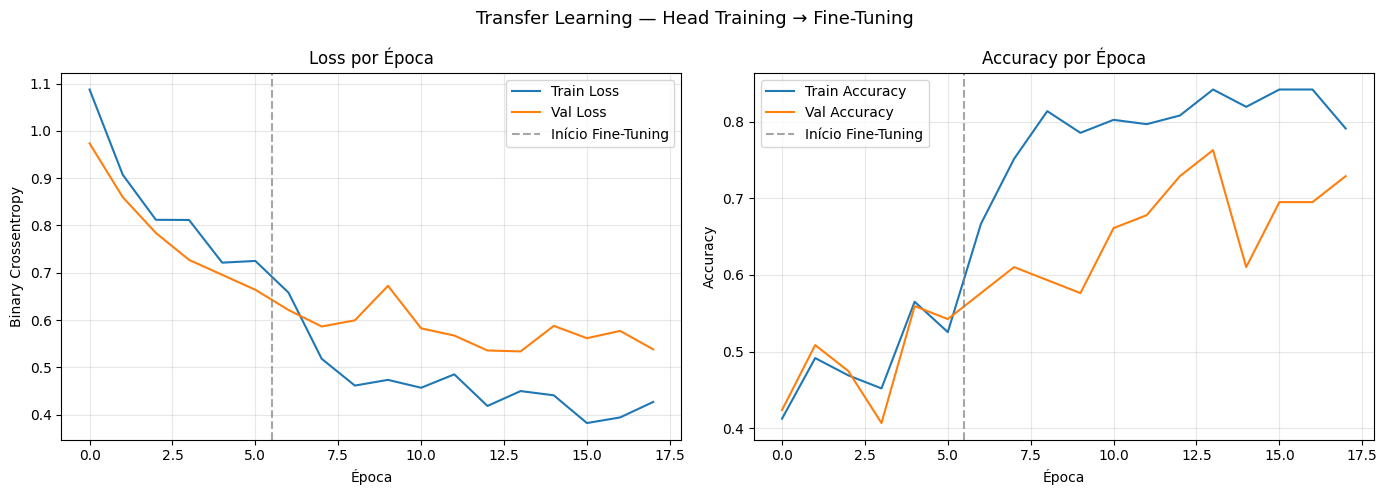

Gráfico salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a08_transfer_learning/training_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(full_history["loss"], label="Train Loss")
axes[0].plot(full_history["val_loss"], label="Val Loss")
axes[0].axvline(x=phase1_epochs - 0.5, color="gray", linestyle="--", alpha=0.7, label="Início Fine-Tuning")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(full_history["accuracy"], label="Train Accuracy")
axes[1].plot(full_history["val_accuracy"], label="Val Accuracy")
axes[1].axvline(x=phase1_epochs - 0.5, color="gray", linestyle="--", alpha=0.7, label="Início Fine-Tuning")
axes[1].set_title("Accuracy por Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Transfer Learning — Head Training → Fine-Tuning", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {OUTPUT_DIR / 'training_curves.png'}")

### Validação da Integração e Avaliação no Conjunto de Teste

Nesta etapa, validamos a integração das camadas de classificação adaptadas (cabeça do modelo) sobre o backbone pré-treinado. A avaliação é realizada no conjunto de teste (`test_ds`), que é estritamente inédito para o modelo, garantindo uma medição realista do poder de generalização alcançado pelo Transfer Learning.

In [ ]:
print("Iniciando predição no conjunto de teste...")

# Extrair os rótulos reais diretamente do dataset de teste para garantir alinhamento
y_true = np.concatenate([y.numpy() for x, y in tf_data["test_ds"]], axis=0)

# Realizar o Forward Pass completo (Inferência) no conjunto de teste
y_pred_prob = model.predict(tf_data["test_ds"])

# Como a camada final usa ativação 'sigmoid' para classificação binária:
# Limiar (threshold) padrão de 0.5 para definir a classe predita
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_scores = y_pred_prob.flatten()

print("Predição concluída com sucesso. Dimensões verificadas:")
print(f" - Rótulos Reais (y_true): {y_true.shape}")
print(f" - Predições (y_pred): {y_pred.shape}")